In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
#import pytorch_lightning as pl
import torch
import anndata as ad
from geome import iterables, transforms, ann2data
from geome.ann2data.by_category import Ann2DataByCategory
import numpy as np
import squidpy as sq
import matplotlib.pyplot as plt
import scanpy as sc

In [3]:
HE22_HUMAN_LUNG_DATA_PATH = '/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/unprocessed_data/he22_cosmx_human_lung.h5ad'

Follow guidelines from [geome notebooks](https://github.com/theislab/geome/blob/main/docs/notebooks/1_iterables_and_iterators.ipynb).
[Contributing guide](https://scanpy.readthedocs.io/en/latest/dev/getting-set-up.html).

In [4]:
adata = sc.read_h5ad(HE22_HUMAN_LUNG_DATA_PATH)
adata

AnnData object with n_obs × n_vars = 771203 × 960
    obs: 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'niche', 'image_id', 'cell_ID', 'sex_ontology_term_id', 'assay_ontology_term_id', 'organism_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'tissue_type', 'condition_id', 'donor_id', 'author_cell_type', 'library_key', 'assay', 'organism', 'sex', 'tissue', 'dataset', 'x', 'y', '_scvi_batch', '_scvi_labels', 'window', 'sliding_window'
    var: 'level_0', 'index', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'adj_matrix_neighbors', 'log1p', 'neighbors', 'niche', 'niche_colors', 'schema_version', 'title', 'umap'
    obsm: 'X_pca', 'X_scvi', 'spatial'
    layers: 'log1p', 'raw'

In [24]:
GRAPH_ID = 'window' # obs variable to split adata on (create graphs from)

In [35]:
adata.obs[GRAPH_ID].cat.categories

Index(['0_0_0', '0_0_1', '0_0_2', '0_0_3', '0_0_4', '0_0_5', '0_0_6', '0_1_0',
       '0_1_1', '0_1_2',
       ...
       '7_5_2', '7_5_3', '7_5_4', '7_5_5', '7_6_0', '7_6_1', '7_6_2', '7_6_3',
       '7_6_4', '7_6_5'],
      dtype='object', length=375)

In [18]:
adata.obs["donor_id"].cat.categories

Index(['Lung5', 'Lung6', 'Lung9', 'Lung12', 'Lung13'], dtype='object')

In [5]:
from graph_transformer_long_range_niches.pp.geome_utils import prepare_geome_dataset
from graph_transformer_long_range_niches.tl.load_config import Config

cfg_path = '/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/src/config_files/He23/he23_gnntrans_niche.yaml'
cfg = Config(cfg_path)
pyg_datas = prepare_geome_dataset(cfg)


Load cfg file...
{'out_dir': 'results', 'wandb': {'use': True, 'project_name': 'GTLongRange', 'run_idx': None}, 'model': {'model_type': 'gnn-transformer', 'n_epochs': 100}, 'optim': {'lr': 0.001, 'wd': '1e-3', 'warm_up': 10, 'seed': 42}, 'dataset': {'h5ad_data': '/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/unprocessed_data/he22_cosmx_human_lung.h5ad', 'name': 'he23', 'description': "CosmX Lung data from He23 with graphs for each .obs['sliding_window'] and prediction node .obs['niche'].", 'prediction_task': 'node', 'prediction_obs': 'niche', 'library_key': 'sliding_window', 'subset_dict': {}, 'spatial_neigbors_kwargs': {'radius': 50, 'coord_type': 'generic'}, 'batch_size': 20, 'train_size': 0.8, 'val_size': 0.2, 'test_size': 0.0}, 'gnn': {'gnn_type': 'GCN', 'num_layers': 2, 'hidden_dim': 256, 'embed_dim': 256, 'dropout': 0.1}, 'transformer': {'d_model': 128, 'n_heads': 4, 'dim_feedforward': 512, 'dropout': 0.3, 'num_layers': 4, 'activation_func': 'relu', 'n

/home/icb/francesca.drummer/1-Projects/geome/src/geome/transforms/categorize.py:38: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  getattr(adata, self.axis)[key] = getattr(adata, self.axis)[key].astype("category")


[Data(x=[1932, 960], edge_index=[2, 1584], y=[1932, 9], obs_names=[1932]), Data(x=[4250, 960], edge_index=[2, 6540], y=[4250, 9], obs_names=[4250]), Data(x=[3427, 960], edge_index=[2, 4182], y=[3427, 9], obs_names=[3427])]
333


### Preprocess

Prepare data format: 

1. calculates addjacency matrix with spatial neighbours
2. select specific data points (?)

In [5]:
from graph_transformer_long_range_niches.tl.load_config import Config  # noqa, register custom modules

cfg_path = '/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/src/config_files/he23_cosmx_human_lung_0_niche_gnn.yaml'
cfg = Config(cfg_path)

Load cfg file...
{'out_dir': 'results', 'wandb': {'use': False, 'project_name': 'GTLongRange', 'name': 'gnn_he23_subgraph_0_niche', 'run_idx': None}, 'model': {'model_type': 'gnn', 'n_epochs': 20}, 'dataset': {'h5ad_data': '/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/unprocessed_data/he22_cosmx_human_lung.h5ad', 'data_name': 'he23_comsx_human_lung_0', 'prediction_task': 'node', 'prediction_obs': 'author_cell_type', 'library_key': 'window', 'subset_dict': {'donor_id': ['Lung5']}, 'spatial_neigbors_kwargs': {'radius': 50, 'coord_type': 'generic'}, 'num_classes': 9, 'batch_size': 10, 'train_size': 0.8, 'val_size': 0.2, 'test_size': 0.0}, 'gnn': {'gnn_type': 'GCN', 'num_layers': 2, 'num_features': 960, 'hidden_dim': 256, 'embed_dim': 256, 'dropout': 0.1}, 'transformer': {'d_model': 128, 'n_heads': 4, 'dim_feedforward': 512, 'dropout': 0.3, 'num_layers': 4, 'activation_func': 'relu', 'num_encoder_layers': 4, 'max_input_len': 4}, 'optim': {'lr': 0.001, 'wd': '1e

In [6]:
adj_matrix_loc = "adj_matrix"
fields = {
    "x": ["X"],
    "y": [f"obs/{cfg.get('dataset/prediction_obs')}"],
    "edge_index": ["uns/edge_index"],
}
category_to_iterate = str(cfg.get('dataset/library_key'))
subset_dict = cfg.get('dataset/subset_dict')
spatial_neigbors_kwargs = cfg.get('dataset/spatial_neigbors_kwargs')
spatial_neigbors_kwargs['library_key'] = category_to_iterate

In [19]:
preprocess = transforms.Compose(
        [
            transforms.Subset(key_value = subset_dict, axis="obs"), 
            #transforms.Categorize(keys=list(subset_dict.keys()) + [cfg.get('dataset/prediction_obs'), cfg.get('dataset/library_key')], axis="obs"),
            transforms.Categorize(keys=[cfg.get('dataset/prediction_obs')], axis="obs"),
        ]
    )

In [20]:
d = {"donor_id": ["Lung5"]}
for k, v in d.items():
    print(k)

donor_id


### Transform

In [21]:
transform = transforms.Compose(
    [
        transforms.AddEdgeIndex(edge_index_key="edge_index", func_args=spatial_neigbors_kwargs, spatial_key="spatial", key_added=adj_matrix_loc),
    ]
)

### Create adata

Adjusting preprocess changes the number of window IDs! If None = 340 window IDs if some preprocess then 141 window ids -> because I subset

In [3]:
# a2d = ann2data.Ann2DataBasic(
#     fields=fields,
#     adata2iter=iterables.ToCategoryIterator("window", axis="obs", preserve_categories = False),
#     preprocess=preprocess,
#     transform=transform,
# ).to_list(adata)

In [26]:
a2d = ann2data.Ann2DataByCategory(
    fields=fields,
    category=category_to_iterate,
    preprocess=preprocess,
    transform=transform,
)

TypeError: Ann2DataByCategory.__init__() got an unexpected keyword argument 'adata2iter'

In [4]:
# datas = list(a2d(adata))
# datas[:3]

In [ ]:
torch.max(datas[1].x)
torch.min(datas[1].x)

## Load from geome

In [1]:
from graph_transformer_long_range_niches.tl.load_config import Config  # noqa, register custom modules
from graph_transformer_long_range_niches.pp.geome_utils import prepare_geome_dataset
from graph_transformer_long_range_niches.pp.datamodule_geome import GraphAnnDataModule

In [2]:
cfg_path = '/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/src/config_files/He23/he23_gnntrans_niche.yaml'

In [3]:
cfg = Config(cfg_path)

Load cfg file...
{'out_dir': 'results', 'wandb': {'use': True, 'project_name': 'GTLongRange', 'run_idx': None}, 'model': {'model_type': 'gnn-transformer', 'n_epochs': 100}, 'optim': {'lr': 0.001, 'wd': '1e-3', 'warm_up': 10, 'seed': 42}, 'dataset': {'h5ad_data': '/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/unprocessed_data/he22_cosmx_human_lung.h5ad', 'name': 'he23_niche_window', 'description': "CosmX Lung data from He23 with graphs for each .obs['window'] and prediction node .obs['niche'].", 'prediction_task': 'node', 'prediction_obs': 'niche', 'library_key': 'window', 'subset_dict': {}, 'spatial_neigbors_kwargs': {'radius': 30, 'coord_type': 'generic'}, 'batch_size': 20, 'train_size': 0.8, 'val_size': 0.2, 'test_size': 0.0}, 'gnn': {'gnn_type': 'GCN', 'num_layers': 2, 'hidden_dim': 256, 'embed_dim': 256, 'dropout': 0.1}, 'transformer': {'d_model': 128, 'n_heads': 4, 'dim_feedforward': 512, 'dropout': 0.3, 'num_layers': 4, 'activation_func': 'relu', 'num_

In [4]:
pyg_data = prepare_geome_dataset(cfg)

/home/icb/francesca.drummer/1-Projects/geome/src/geome/transforms/categorize.py:38: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  getattr(adata, self.axis)[key] = getattr(adata, self.axis)[key].astype("category")


: 

In [ ]:
pyg_data

[Data(x=[1169, 960], edge_index=[2, 42], y=[1169, 9]),
 Data(x=[2573, 960], edge_index=[2, 244], y=[2573, 9]),
 Data(x=[2527, 960], edge_index=[2, 206], y=[2527, 9]),
 Data(x=[2304, 960], edge_index=[2, 114], y=[2304, 9]),
 Data(x=[1714, 960], edge_index=[2, 46], y=[1714, 9]),
 Data(x=[1524, 960], edge_index=[2, 68], y=[1524, 9]),
 Data(x=[1816, 960], edge_index=[2, 102], y=[1816, 9]),
 Data(x=[1487, 960], edge_index=[2, 58], y=[1487, 9]),
 Data(x=[887, 960], edge_index=[2, 44], y=[887, 9]),
 Data(x=[496, 960], edge_index=[2, 40], y=[496, 9]),
 Data(x=[672, 960], edge_index=[2, 52], y=[672, 9]),
 Data(x=[425, 960], edge_index=[2, 28], y=[425, 9]),
 Data(x=[442, 960], edge_index=[2, 32], y=[442, 9]),
 Data(x=[471, 960], edge_index=[2, 18], y=[471, 9]),
 Data(x=[2149, 960], edge_index=[2, 194], y=[2149, 9]),
 Data(x=[457, 960], edge_index=[2, 38], y=[457, 9]),
 Data(x=[1735, 960], edge_index=[2, 118], y=[1735, 9]),
 Data(x=[366, 960], edge_index=[2, 36], y=[366, 9]),
 Data(x=[1548, 960],

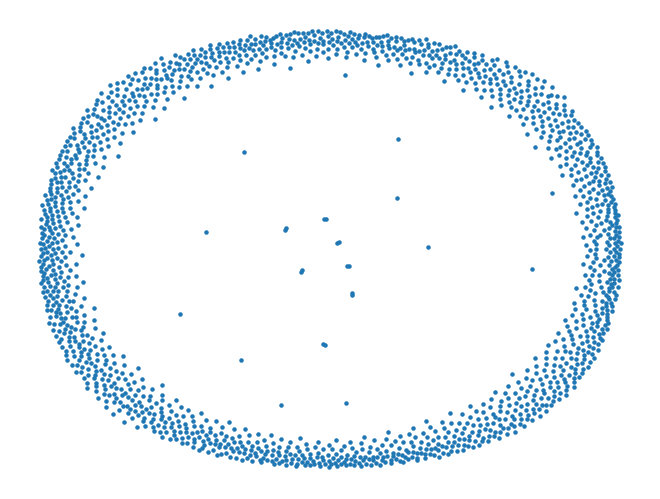

In [25]:
import networkx as nx
import torch_geometric

data = pyg_data[150]

g = torch_geometric.utils.to_networkx(data, to_undirected=True)
nx.draw(g, node_size = 5, edge_color = "tab:blue", node_color = "tab:blue")

In [6]:
adj_matrix_loc = "adj_matrix"
prediction_obs = cfg.get('dataset/prediction_obs')
category_to_iterate = str(cfg.get('dataset/library_key'))
subset_dict = cfg.get('dataset/subset_dict')
spatial_neigbors_kwargs = cfg.get('dataset/spatial_neigbors_kwargs')
spatial_neigbors_kwargs['library_key'] = category_to_iterate

fields = {
    "x": ["X"],
    "y": [f"obs/{prediction_obs}"],
    "edge_index": ["uns/edge_index"],
}

preprocess = transforms.Compose(
    [
        transforms.Subset(key_value = subset_dict, axis="obs"), 
        transforms.Categorize(keys=[prediction_obs], axis="obs"),
        #transforms.AddEdgeIndex(edge_index_key="edge_index", func_args=spatial_neigbors_kwargs, spatial_key="spatial", key_added=adj_matrix_loc)
    ]
)

transform = transforms.Compose(
    
    [
        transforms.AddEdgeIndex(edge_index_key="edge_index", func_args=spatial_neigbors_kwargs, spatial_key="spatial", key_added=adj_matrix_loc),
    ]
)

adata = sc.read_h5ad(cfg.get('dataset/h5ad_data'))

a2d = ann2data.Ann2DataBasic(
    fields=fields,
    adata2iter=iterables.ToCategoryIterator("window", axis="obs", preserve_categories = [prediction_obs]),
    preprocess=preprocess,
    transform=transform,
)

datas = list(a2d(adata))

/home/icb/francesca.drummer/1-Projects/geome/src/geome/transforms/categorize.py:36: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  getattr(adata, self.axis)[key] = getattr(adata, self.axis)[key].astype("category")


author_cell_type


In [10]:
datas[:10]

[Data(x=[1169, 960], edge_index=[2, 808], y=[1169, 18]),
 Data(x=[2573, 960], edge_index=[2, 3960], y=[2573, 18]),
 Data(x=[2527, 960], edge_index=[2, 3610], y=[2527, 18]),
 Data(x=[2304, 960], edge_index=[2, 2600], y=[2304, 18]),
 Data(x=[1714, 960], edge_index=[2, 1364], y=[1714, 18]),
 Data(x=[1524, 960], edge_index=[2, 1254], y=[1524, 18]),
 Data(x=[1816, 960], edge_index=[2, 1648], y=[1816, 18]),
 Data(x=[1487, 960], edge_index=[2, 1244], y=[1487, 18]),
 Data(x=[887, 960], edge_index=[2, 938], y=[887, 18]),
 Data(x=[496, 960], edge_index=[2, 666], y=[496, 18])]

In [11]:
len(datas[0].y[1])

18

In [12]:
import torch

y_true = [torch.empty(3), torch.empty(3)]

In [13]:
y_true

[tensor([3.5099e-30, 0.0000e+00, 8.6985e+11]),
 tensor([1.0907e+11, 0.0000e+00, 3.6392e+02])]

### Datamodule with lightning.Dataset for PyTorch Geometric

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
train_size = 0.8
val_size = 0.2
test_size = 0.0

In [10]:
train_ds, val_ds = train_test_split(datas, train_size=train_size, test_size=val_size+test_size, random_state=42)
if test_size > 0.0:
    val_ds, test_ds = train_test_split(val_ds, train_size=1-test_size, test_size=test_size, random_state=42)

In [11]:
print(len(train_ds), len(val_ds))
if test_size >0.0:
    print(len(test_ds))

112 29


In [12]:
from torch_geometric.data.lightning import LightningDataset

In [19]:
dataset = LightningDataset(train_ds, val_ds)

In [24]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_ds, batch_size=int(cfg.get('dataset/batch_size')), shuffle=True)

In [28]:
for i in train_loader:
    print(i)

TypeError: 'DataLoader' object is not callable